In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from varengine.config import TICKERS, START, END
from varengine.data import load_prices
from varengine.returns import simple_returns, portfolio_losses
from varengine.historical import rolling_hs, rolling_fhs
from varengine.parametric import rolling_normal, rolling_t, rolling_ewma, fit_t
from varengine.volatility import ewma_variance
from varengine.montecarlo import rolling_mc
from varengine.backtest import (violations, kupiec, christoffersen_independence,
                                christoffersen_cc, basel_zone, es_backtest,
                                backtest, backtest_all, common_index)

prices = load_prices(TICKERS, START, END)
rets = simple_returns(prices)
w = np.full(len(TICKERS), 1 / len(TICKERS))
loss = portfolio_losses(rets, w)

nu_z, _ = fit_t((loss / np.sqrt(ewma_variance(loss))).dropna().iloc[:500])
print("nu_z:", round(nu_z, 2))

models = {
    "HS":     rolling_hs(loss),
    "Normal": rolling_normal(loss),
    "t":      rolling_t(loss),
    "EWMA-N": rolling_ewma(loss),
    "EWMA-t": rolling_ewma(loss, dist="t", nu=nu_z),
    "FHS":    rolling_fhs(loss),
    "MC-N":   rolling_mc(rets, w),
    "MC-t":   rolling_mc(rets, w, dist="t", nu=nu_z),
}
print({k: len(v) for k, v in models.items()})

Loaded cached prices: 2015-01-02 to 2026-09-18
nu_z: 5.2
{'HS': 2495, 'Normal': 2495, 't': 2495, 'EWMA-N': 2994, 'EWMA-t': 2994, 'FHS': 2494, 'MC-N': 2495, 'MC-t': 2495}


In [2]:
print(kupiec(np.r_[np.ones(8), np.zeros(242)])) # LR_uc ~ 7.73, p ~ 0.005
print(kupiec(np.r_[np.ones(25), np.zeros(2475)])) # exactly expected -> LR_uc = 0

spread = np.zeros(1000); spread[::100] = 1 # 1 violation every 100 days
clust  = np.zeros(1000); clust[500:510] = 1 # ten in a row

print("Kupiec identical: ",
      kupiec(spread)["LR_uc"], kupiec(clust)["LR_uc"])
print("independence differs:",
      round(christoffersen_independence(spread)["LR_ind"], 2),
      round(christoffersen_independence(clust)["LR_ind"], 2))

{'T': 250, 'violations': 8, 'expected': 2.500000000000002, 'rate': 0.032, 'LR_uc': np.float64(7.7335507244945205), 'p_uc': np.float64(0.0054204051941277994)}
{'T': 2500, 'violations': 25, 'expected': 25.00000000000002, 'rate': 0.01, 'LR_uc': np.float64(-0.0), 'p_uc': np.float64(1.0)}
Kupiec identical:  -0.0 -0.0
independence differs: 0.18 89.69


In [3]:
pd.set_option("display.width", 200)

idx = common_index(loss, models)
results = backtest_all(loss, models, alpha=0.99)
print(f"{len(idx)} common days, from {idx[0].date()} to {idx[-1].date()}")
print(f"expected violations: {results['expected'].iloc[0]:.1f}")
results.round(4)

2494 common days, from 2016-12-15 to 2026-09-18
expected violations: 24.9


,violations,expected,rate,LR_uc,p_uc,LR_ind,p_ind,LR_cc,p_cc,basel_zone,Z2
HS,28,24.94,0.0112,0.3648,0.5459,19.9845,0.0000,20.3493,0.0000,green,0.3167
Normal,39,24.94,0.0156,6.8331,0.0089,18.2525,0.0000,25.0856,0.0000,green,1.1788
t,29,24.94,0.0116,0.6344,0.4257,19.2512,0.0000,19.8856,0.0000,green,0.4720
EWMA-N,55,24.94,0.0221,27.2421,0.0000,1.9793,0.1595,29.2214,0.0000,yellow,1.5517
EWMA-t,33,24.94,0.0132,2.3886,0.1222,0.5498,0.4584,2.9384,0.2301,green,0.3596
FHS,35,24.94,0.0140,3.6423,0.0563,0.4190,0.5174,4.0613,0.1312,green,0.3944
MC-N,55,24.94,0.0221,27.2421,0.0000,1.9793,0.1595,29.2214,0.0000,yellow,1.5771
MC-t,35,24.94,0.0140,3.6423,0.0563,2.7323,0.0983,6.3746,0.0413,green,0.4528


In [4]:
hits = pd.DataFrame({name: violations(loss.loc[idx], m["VaR"].loc[idx])
                     for name, m in models.items()})
by_year = hits.groupby(hits.index.year).sum()
by_year

,HS,Normal,t,EWMA-N,EWMA-t,FHS,MC-N,MC-t
2016,0,0,0,0,0,0,0,0
2017,0,0,0,1,1,1,1,1
2018,1,1,1,7,3,9,7,4
2019,2,4,2,9,5,5,9,5
2020,14,19,15,6,4,4,6,4
2021,1,1,1,6,4,2,6,4
2022,2,2,1,6,4,3,6,4
2023,2,2,2,4,4,3,4,4
2024,2,3,2,6,2,2,6,2
2025,3,4,4,6,4,4,6,4


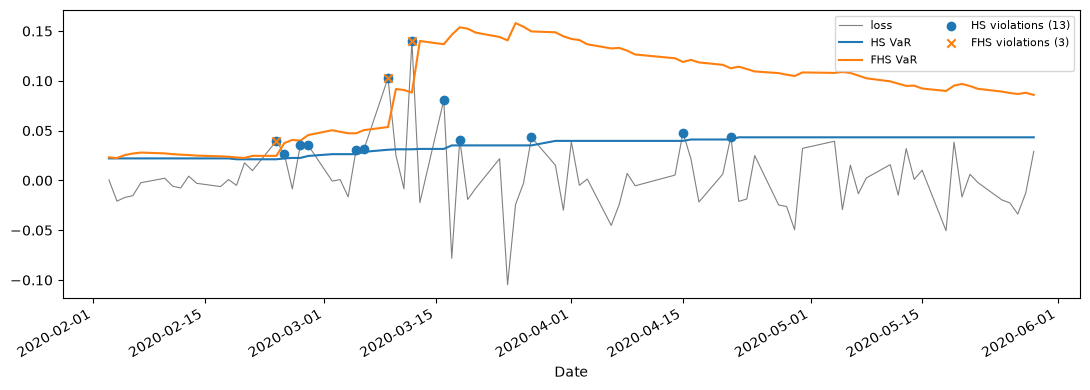

In [5]:
window = slice("2020-02-01", "2020-05-31")

ax = loss.loc[window].plot(figsize=(11, 4), color="grey", lw=0.8, label="loss")
for name in ["HS", "FHS"]:
    models[name]["VaR"].loc[window].plot(ax=ax, label=f"{name} VaR")

for name, style in [("HS", "o"), ("FHS", "x")]:
    h = hits[name].loc[window]
    dates = h[h == 1].index
    ax.scatter(dates, loss.loc[dates], marker=style, zorder=3,
               label=f"{name} violations ({len(dates)})")

ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

In [6]:
results.to_csv("../data/backtest_results.csv")

In [7]:
def build_models(loss, rets, w, nu_z, alpha=0.99):
    """All eight models at one confidence level."""
    return {
        "HS":     rolling_hs(loss, alpha=alpha),
        "Normal": rolling_normal(loss, alpha=alpha),
        "t":      rolling_t(loss, alpha=alpha),
        "EWMA-N": rolling_ewma(loss, alpha=alpha),
        "EWMA-t": rolling_ewma(loss, alpha=alpha, dist="t", nu=nu_z),
        "FHS":    rolling_fhs(loss, alpha=alpha),
        "MC-N":   rolling_mc(rets, w, alpha=alpha),
        "MC-t":   rolling_mc(rets, w, alpha=alpha, dist="t", nu=nu_z),
    }

In [8]:
tables = {}
for a in (0.99, 0.95):
    m = build_models(loss, rets, w, nu_z, alpha=a)
    tables[a] = backtest_all(loss, m, alpha=a)
    print(f"\n=== alpha = {a}   expected violations = {tables[a]['expected'].iloc[0]:.1f} ===")
    print(tables[a][["violations", "rate", "LR_uc", "p_uc",
                     "p_ind", "p_cc", "Z2"]].round(4).to_string())

tables[0.95].to_csv("../data/backtest_results_95.csv")


=== alpha = 0.99   expected violations = 24.9 ===
        violations    rate    LR_uc    p_uc   p_ind    p_cc      Z2
HS              28  0.0112   0.3648  0.5459  0.0000  0.0000  0.3167
Normal          39  0.0156   6.8331  0.0089  0.0000  0.0000  1.1788
t               29  0.0116   0.6344  0.4257  0.0000  0.0000  0.4720
EWMA-N          55  0.0221  27.2421  0.0000  0.1595  0.0000  1.5517
EWMA-t          33  0.0132   2.3886  0.1222  0.4584  0.2301  0.3596
FHS             35  0.0140   3.6423  0.0563  0.5174  0.1312  0.3944
MC-N            55  0.0221  27.2421  0.0000  0.1595  0.0000  1.5771
MC-t            35  0.0140   3.6423  0.0563  0.0983  0.0413  0.4528

=== alpha = 0.95   expected violations = 124.7 ===
        violations    rate   LR_uc    p_uc   p_ind    p_cc      Z2
HS             110  0.0441  1.8963  0.1685  0.0003  0.0006 -0.0304
Normal          96  0.0385  7.5262  0.0061  0.0000  0.0000 -0.0076
t              109  0.0437  2.1691  0.1408  0.0000  0.0000  0.0068
EWMA-N         12